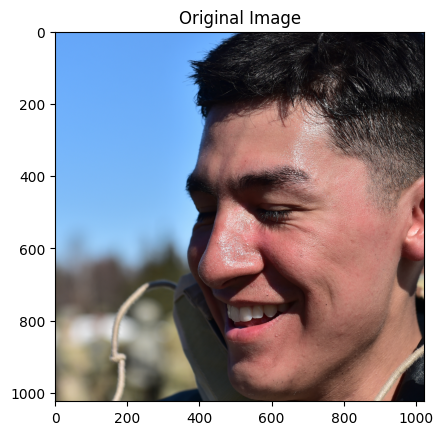

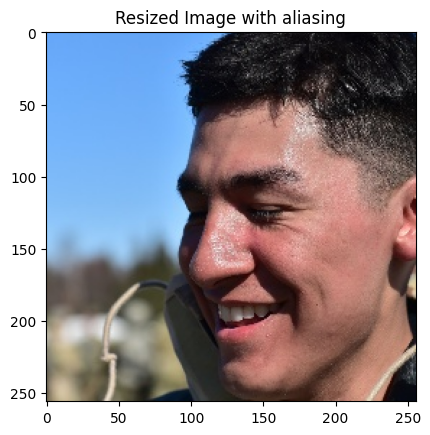

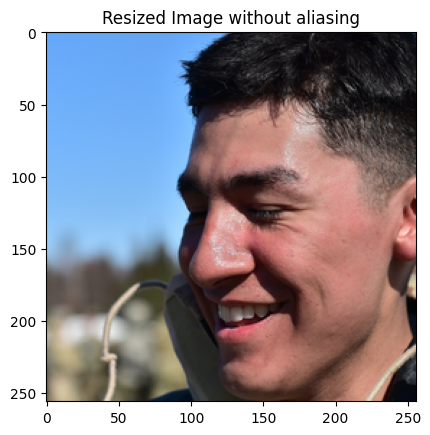

In [2]:
import os, glob, tqdm
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

sj_id = '69809.jpg'
ffhq_path = f'/data/mint/DPM_Dataset/ffhq_256_with_anno/ffhq_256/valid/{sj_id}'

sub_folder = list(np.arange(0, 70000, 3000))
# Found which sub-folder the image is in
sub_id = int(sj_id.split('.')[0]) // 3000 * 3000
full_res = f'/data/mint/DPM_Dataset/ffhq_256_with_anno/images1024x1024/{sub_id}/{sj_id.replace(".jpg", ".png")}'

full_res_img = Image.open(full_res)
resized_img = Image.open(ffhq_path)
plt.imshow(full_res_img)
plt.title('Original Image')
plt.show()
plt.imshow(resized_img)
plt.title('Resized Image with aliasing')
plt.show()
# Resize without having aliasing 
resized_img_fixed = full_res_img.resize((256, 256), Image.LANCZOS)
plt.title('Resized Image without aliasing')
plt.imshow(resized_img_fixed)
plt.show()

In [3]:
# Resize the image to 256x256 with anti-aliasing
out_path = '/data/mint/DPM_Dataset/ffhq_256_with_anno/ffhq_256_no_aliasing_png/'
set_ = 'valid'
os.makedirs(f'{out_path}/{set_}/', exist_ok=True)
for path in tqdm.tqdm(glob.glob(f'/data/mint/DPM_Dataset/ffhq_256_with_anno/ffhq_256/{set_}/*.jpg')):
    img_name = path.split('/')[-1]
    img_name_digits = int(img_name.replace('.jpg', ''))
    # Get the full resolution image path
    if set_ == 'valid':
        sub_id = int(img_name.split('.')[0]) // 1000 * 1000
    elif set_ == 'train':
        sub_id = int(img_name.split('.')[0]) // 1000 * 1000
    else:
        raise ValueError('[#] Set must be either train or valid...')
    if img_name_digits < 10000:
        # Add 0 to have 5 digits for the sub-folder
        sub_id = f'{sub_id:05}'
        img_name = f'{img_name_digits:05}.jpg'
        
    full_res_path = f'/data/mint/DPM_Dataset/ffhq_256_with_anno/images1024x1024/{sub_id}/{img_name.replace(".jpg", ".png")}'
    full_res_img = Image.open(full_res_path)
    resized_img_fixed = full_res_img.resize((256, 256), Image.LANCZOS)
    resized_img_fixed.save(f'{out_path}/{set_}/{img_name.replace(".jpg", ".png")}', format="PNG")

  0%|          | 37/10000 [00:02<08:59, 18.46it/s]

100%|██████████| 10000/10000 [09:09<00:00, 18.19it/s]
